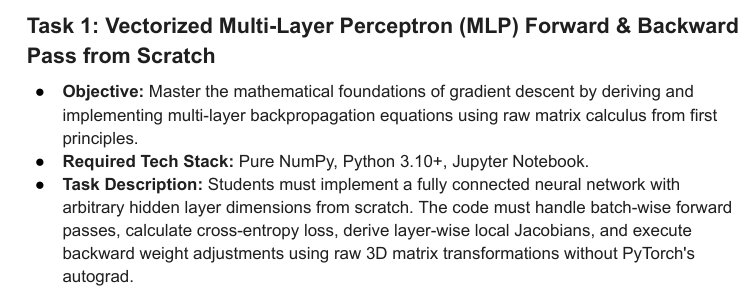

In [1]:
!pip install numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

X = np.random.randn(300, 2)

y = np.zeros(300, dtype=int)

y[X[:, 0] + X[:, 1] > 1] = 1
y[X[:, 0] - X[:, 1] > 1] = 2

Y = np.eye(3)[y]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (300, 2)
Y shape: (300, 3)


In [4]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)

In [5]:
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [6]:
def cross_entropy(y_true, y_pred):
    eps = 1e-8
    return -np.mean(
        np.sum(y_true * np.log(y_pred + eps), axis=1)
    )

In [7]:
input_size = 2
hidden1 = 16
hidden2 = 16
output_size = 3

W1 = np.random.randn(input_size, hidden1) * 0.1
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.1
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.1
b3 = np.zeros((1, output_size))

In [8]:
def forward(X):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    cache = (X, Z1, A1, Z2, A2, Z3, A3)

    return A3, cache

In [9]:
predictions, cache = forward(X)

print("Prediction shape:", predictions.shape)
print("First prediction:")
print(predictions[0])

Prediction shape: (300, 3)
First prediction:
[0.3324966  0.33574751 0.33175589]


In [10]:
print(np.sum(predictions[0]))

1.0


In [11]:
def backward(Y, cache):

    X, Z1, A1, Z2, A2, Z3, A3 = cache

    m = X.shape[0]

    # Output layer
    dZ3 = (A3 - Y) / m

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Hidden layer 2
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer 1
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

In [12]:
learning_rate = 0.1
epochs = 1000

loss_history = []

for epoch in range(epochs):

    # Forward
    predictions, cache = forward(X)

    # Loss
    loss = cross_entropy(Y, predictions)

    # Backward
    dW1, db1, dW2, db2, dW3, db3 = backward(Y, cache)

    # Update
    W1[:] -= learning_rate * dW1
    b1[:] -= learning_rate * db1

    W2[:] -= learning_rate * dW2
    b2[:] -= learning_rate * db2

    W3[:] -= learning_rate * dW3
    b3[:] -= learning_rate * db3

    loss_history.append(loss)

    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)

Epoch: 0 Loss: 1.096394831856214
Epoch: 100 Loss: 0.6811979160844602
Epoch: 200 Loss: 0.24711108817821356
Epoch: 300 Loss: 0.12990480477550756
Epoch: 400 Loss: 0.09386933073370486
Epoch: 500 Loss: 0.07594443116164827
Epoch: 600 Loss: 0.06527683448238823
Epoch: 700 Loss: 0.05800772340746479
Epoch: 800 Loss: 0.052467345487543886
Epoch: 900 Loss: 0.048104785469084914


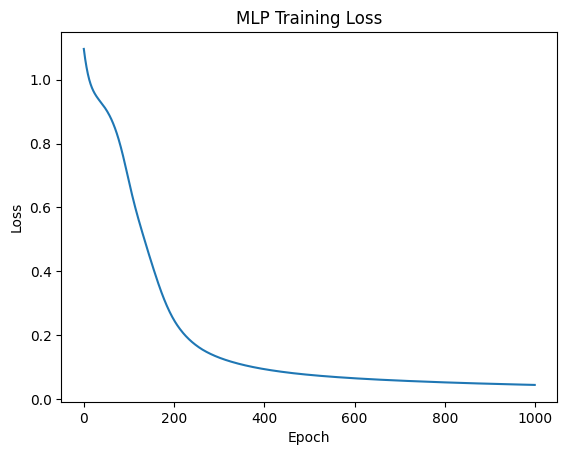

In [13]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")

plt.show()

In [14]:
predictions, _ = forward(X)

predicted_classes = np.argmax(predictions, axis=1)

accuracy = np.mean(predicted_classes == y)

print("Accuracy:", accuracy)

Accuracy: 0.99


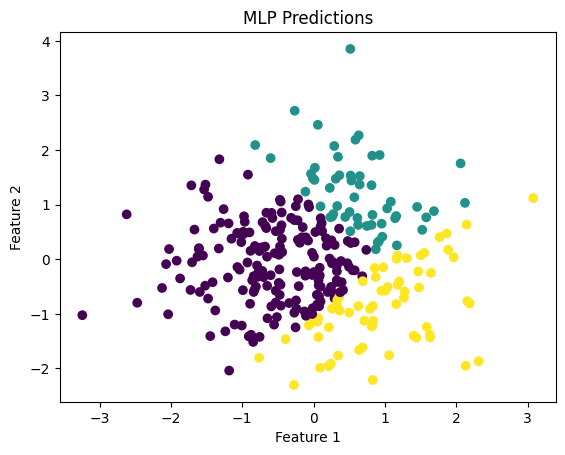

In [15]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=predicted_classes
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("MLP Predictions")

plt.show()